In [37]:
# LIBRARIES
import pandas as pd
import os
import numpy as np
from pandas.tseries.offsets import BDay
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import Data_Functions as DF
import Brent_Functions as BF
import WTI_Functions as WTI_F
import TFM_Functions as TFM_F
import ECF_Functions as ECF_F
import RV_Functions as RV
import Vol_Fun_Sep as V_F_S
import LHAR_CJ as lhar_cj

# Loading and ordering Data

# Sincronizing Data

Nel contesto dell' applicazione dello stimatore TSRV c'è una sfumatura importante:

- Metodo Standard (Previous Tick Interpolation): Si prende l'ultimo prezzo scambiato in quel secondo. Se in un secondo non ci sono scambi, si tiene il prezzo del secondo prima. Questo preserva la struttura del "rumore" che il TSRV vuole misurare.

- Metodo Robusto (Median): Si prende la mediana dei prezzi in quel secondo. Questo riduce molto il rumore prima di applicare lo stimatore. È "più pulito", ma rischi di eliminare proprio quel rumore che il TSRV dovrebbe correggere matematicamente.

# BRN
#### 1- Tick Size ($0.01) e Metodo di Aggregazione:

Il contratto specifica un Minimum Price Fluctuation di $0.01. Questo significa che i prezzi sono discreti ($38.01, 38.02, ecc.).Implicazione: Dobbiamo usare method='last' (Previous Tick Interpolation).

Perché non la Mediana? 
Se usassimo la mediana (es. tra 38.01 e 38.02), otterremmo $38.015$. Questo prezzo non esiste nella realtà del mercato. Creare "prezzi artificiali" distruggerebbe la struttura del microstructure noise (il saltellamento tra Bid e Ask) che lo stimatore TSRV è progettato proprio per misurare e correggere. Usando l'ultimo prezzo, preserviamo la natura "a scatti" del mercato.

#### 2- Orari di Trading e Liquidità

Il Brent viene scambiato elettronicamente quasi 24/24h, ma la liquidità non è uniforme.

Settlement: Avviene alle 19:28 (London Time).

Implicazione: Per uno studio robusto, è consigliabile filtrare i dati per includere solo le ore liquide (es. 08:00 - 20:00 o la sessione estesa 01:00 - 23:00), escludendo i momenti "morti" dove il prezzo non cambia per molti secondi (che porterebbero i rendimenti a zero, diluendo la volatilità).

#### 3- Data di Scadenza (Expiration)
La regola è complessa: the Brent futures contract expires at the end of the month preceding the month of delivery by two months.

Implicazione: Dobbiamo assicurarci di non includere dati successivi alla data di scadenza del contratto, dove i volumi crollano e il prezzo perde significato (o diventa spot).

## Expiration

L'ICE (Intercontinental Exchange) ha cambiato le regole di scadenza del Brent proprio nel 2016.

Per i contratti da Marzo 2016 (H16 nei nostri Raw Data) in poi, valgono messe in atto le regole nuove ("Month Ahead", scadenza fine mese).

Mentre per i contratti fino a Febbraio 2016 (incluso F16 e G16 nei Raw data), valgono le vecchie regole.

Vecchia Regola (per F16 nei nostri Raw Data): La scadenza avveniva circa il 16 del mese precedente alla consegna. Nel caso specifico di BRN_F16 (Gennaio 2016):

- Data di Scadenza Calcolata: 16 Dicembre 2015.

- Raw Data: Arrivano fino al 16 Dicembre.

### La Regola Ufficiale (Pre-Marzo 2016)

La regola testuale rilasciata dall' ICE era:

"Trading shall cease on the Business Day immediately preceding either: 

- the 15th calendar day before the first calendar day of the contract month, if such 15th day is a Business Day; or 

- if such 15th day is not a Business Day, the next preceding Business Day."

### Step by step Explanation
- Prendiamo il primo giorno del mese del contratto: 1 Gennaio 2016.

- Andiamo indietro di 15 giorni solari esatti: arriviamo al 17 Dicembre 2015.

- Controlliamo se il 17 Dicembre è lavorativo (Business Day):

- Il 17 Dic 2015 era Giovedì (lavorativo).

- La regola dice: La scadenza è il Business Day immediatamente precedente a questo giorno.

- Il giorno lavorativo prima di Giovedì 17 è Mercoledì 16 Dicembre 2015.

Dunque, il contratto scadeva esattamente il 16 Dicembre. I tuoi dati arrivano fino al 16, quindi la nostra Data Quality è corretta e completa.

In [38]:
# PLOT DEI DATI RAW HOURLY
# DF.plot_hourly_distribution(df_brent, title="Hourly Trade Distribution", valid_start = 1, valid_end = 24)

### Trading Hours

Per ottenere stime di volatilità (TSRV) robuste e non distorte dal "silenzio notturno", tagliamo le code estreme.

L'orario 08:00 - 20:00 (Orario di Londra) sembra perfetto per catturare il 92% dei dati (11.066 su 11.969) eliminando però il 100% delle ore "zombie".

### Tick size and Aggregation Method

# Clean Data Automation + RV Calculation
## BRN

In [39]:
input_dir = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/BRN"  
final_brent = BF.process_brent_dataset(input_dir)
final_brent.head(10)

,Realized Volatility
Datetime,
2015-12-15,0.001112
2015-12-16,0.000592
2015-12-17,0.000084
2015-12-18,0.000427
2015-12-21,0.000185
2015-12-22,0.000178
2015-12-23,0.000604
2015-12-24,0.000234
2015-12-28,0.000025


## WBS

In [40]:
input_dir = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/WBS"
final_wbs = WTI_F.process_wbs_dataset(input_dir)
final_wbs.head(10)

,Realized Volatility
Datetime,
2015-12-15,0.000229
2015-12-16,0.001148
2015-12-17,0.000127
2015-12-18,0.000072
2015-12-21,0.000355
2015-12-22,0.000219
2015-12-23,0.000245
2015-12-24,0.000437
2015-12-28,0.000312


## TFM

In [41]:
input_dir = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/TFM"
final_tfm = TFM_F.process_tfm_dataset(input_dir)
final_tfm.head(10)

,Realized Volatility
Datetime,
2015-12-15,0.000007
2015-12-16,0.000270
2015-12-17,0.000011
2015-12-18,0.000116
2015-12-21,0.000347
2015-12-22,0.000129
2015-12-23,0.000182
2015-12-24,0.000208
2015-12-28,0.000419


## ECF

In [42]:
input_dir = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/ECF"
final_ecf = ECF_F.process_ecf_dataset(input_dir)
final_ecf.head(10)

/Users/viscontitommi/Desktop/S.P./RV_Functions.py:17: RuntimeWarning: divide by zero encountered in log
  log_returns = np.diff(np.log(prices))
/Users/viscontitommi/Desktop/S.P./RV_Functions.py:17: RuntimeWarning: divide by zero encountered in log
  log_returns = np.diff(np.log(prices))


,Realized Volatility
Datetime,
2015-12-15,0.000133
2015-12-16,0.000053
2015-12-17,0.000018
2015-12-18,0.000102
2015-12-21,0.000083
2015-12-22,0.000592
2015-12-23,0.000051
2015-12-24,0.000075
2015-12-28,0.000107


# Summary Statistics Table

In [43]:
df_stats = RV.create_statistics_table(final_brent, final_wbs, final_ecf, final_tfm)
display(df_stats)

Ticker,BRN,WTI,ECF,TFM
Mean,4.636593e-04,7.101338e-04,1.142894e-03,2.032195e-03
Std Dev,1.321049e-03,6.866810e-03,2.875298e-03,5.994896e-03
Min,4.617858e-08,4.827151e-08,3.976901e-08,2.037307e-07
Max,2.874012e-02,2.527444e-01,4.687659e-02,8.143615e-02
Ann. Vol (%),3.418218e+01,4.230292e+01,5.366649e+01,7.156209e+01


In [44]:
# FOLDERS DIRECTORY
folder_brn = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/BRN"
folder_wti = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/WBS"
folder_tfm = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/TFM"
folder_ecf = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/ECF"

## BRN

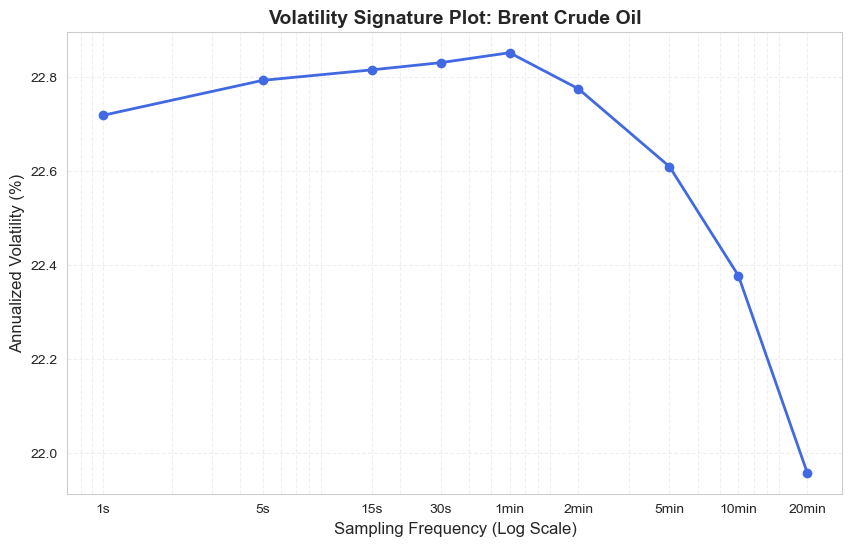

In [45]:
data_brn, seconds = BF.run_brent_signature_analysis(folder_brn)
RV.plot_signature(data_brn, seconds, "Brent Crude Oil")

## WBS

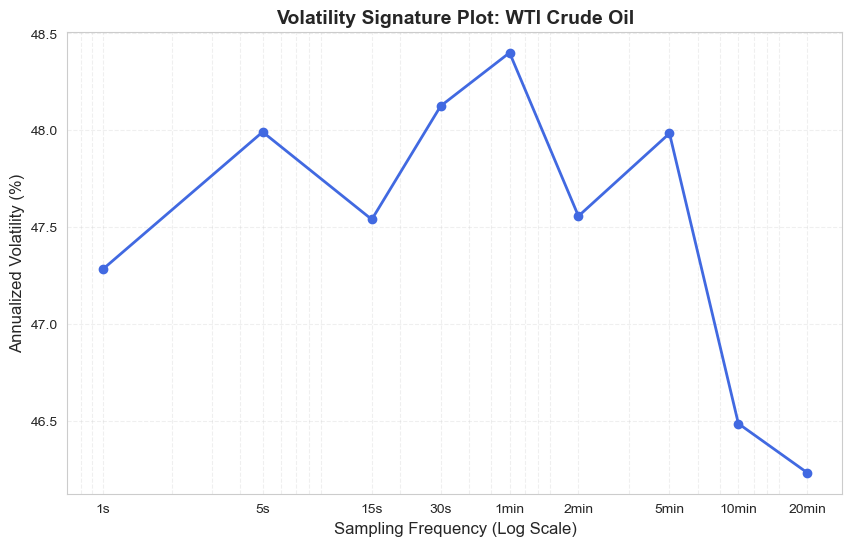

In [46]:
data_wti, seconds = WTI_F.run_wti_signature_analysis(folder_wti)
RV.plot_signature(data_wti, seconds, "WTI Crude Oil")

## TFM

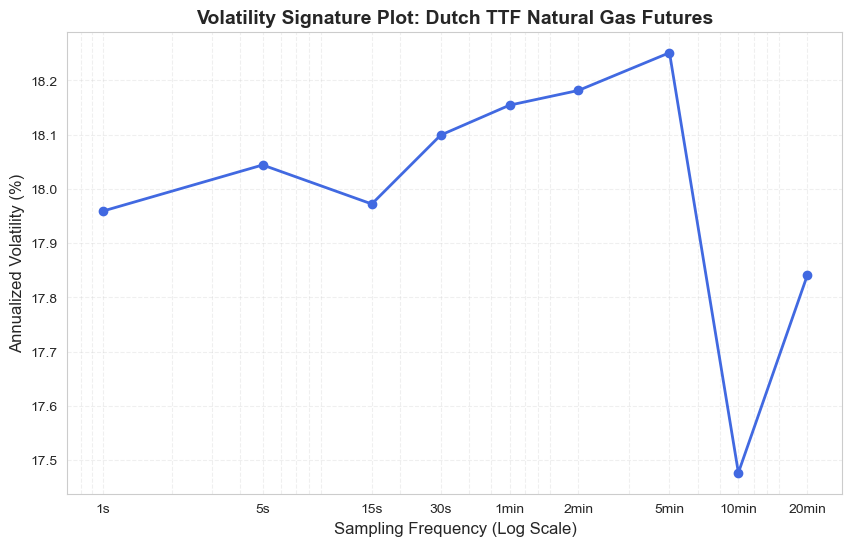

In [47]:
data_tfm, seconds = TFM_F.run_tfm_signature_analysis(folder_tfm)
RV.plot_signature(data_tfm, seconds, "Dutch TTF Natural Gas Futures")

## ECF

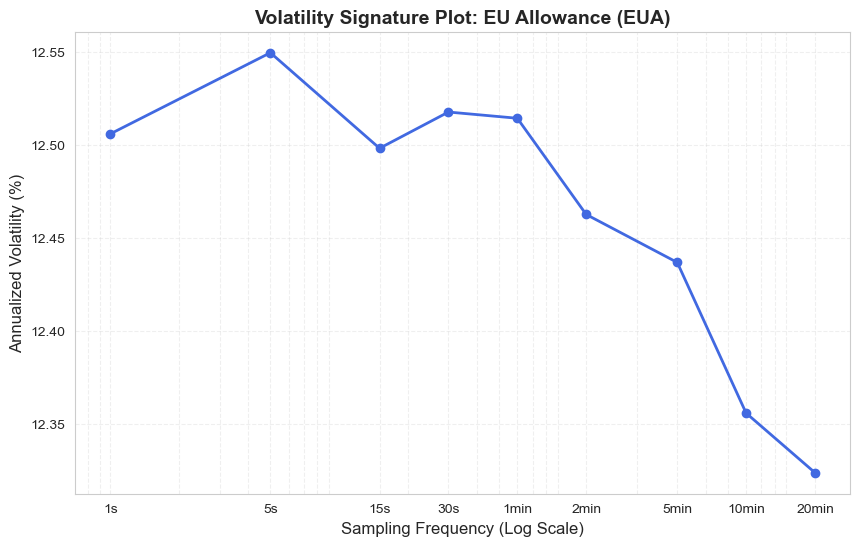

In [48]:
data_ecf, seconds = ECF_F.run_ecf_signature_analysis(folder_ecf)
RV.plot_signature(data_ecf, seconds, "EU Allowance (EUA)")

# TSRV - K Sensitivity Analysis

## BRN

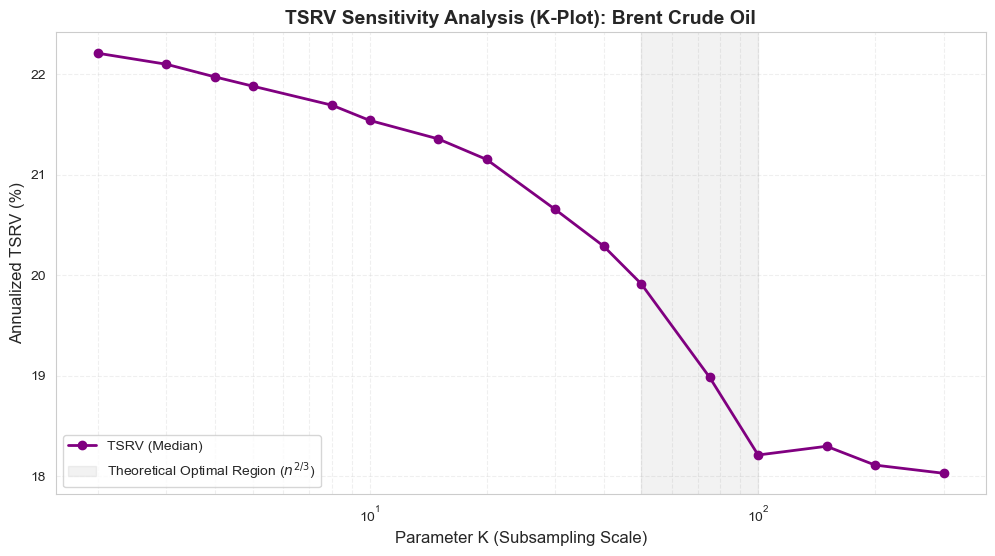

In [49]:
tsrv_data_brent = RV.compute_tsrv_sensitivity_data(folder_brn, "BRN", n_files=50)
RV.plot_tsrv_sensitivity(tsrv_data_brent, "Brent Crude Oil")

## WBS

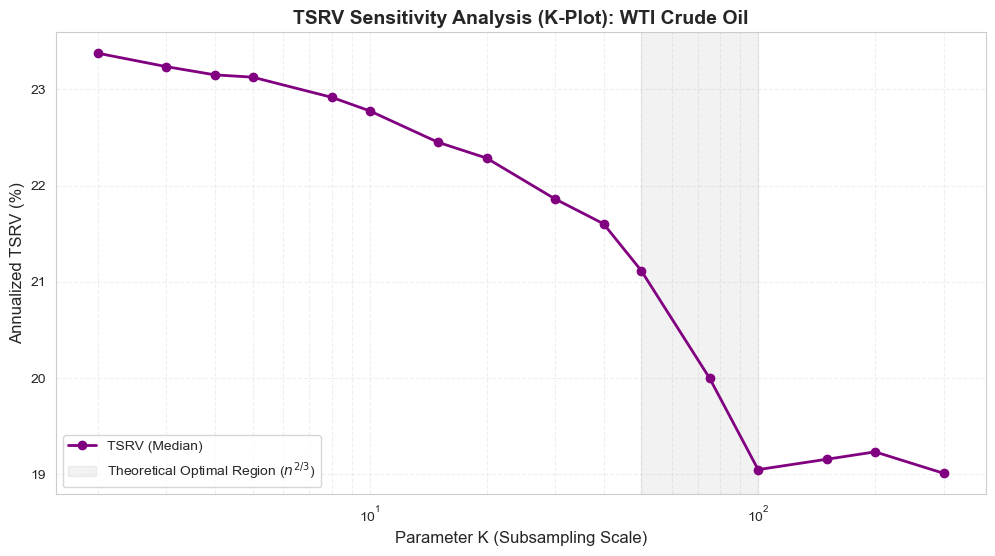

In [50]:
tsrv_data_wti = RV.compute_tsrv_sensitivity_data(folder_wti, "WBS", n_files=50)
RV.plot_tsrv_sensitivity(tsrv_data_wti, "WTI Crude Oil")

## TFM

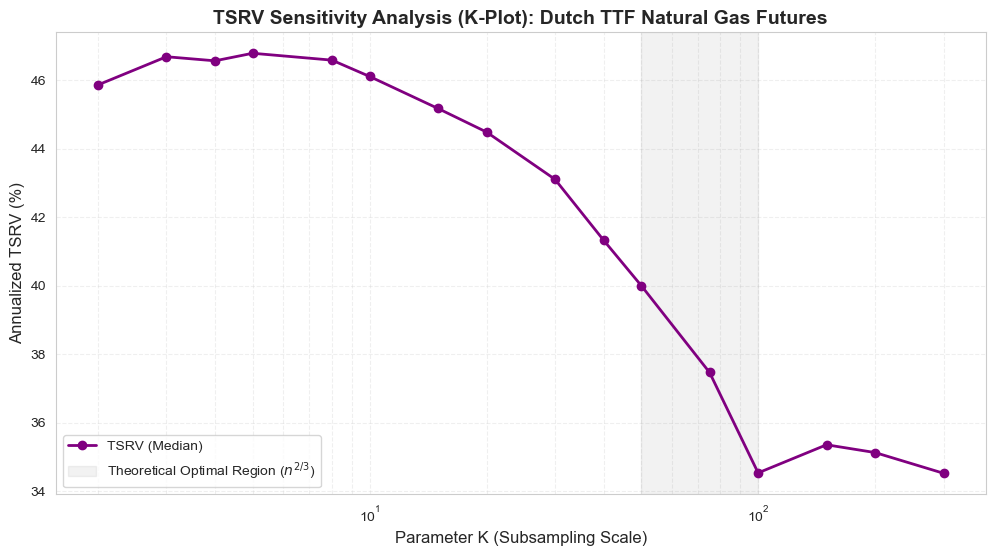

In [51]:
tsrv_data_tfm = RV.compute_tsrv_sensitivity_data(folder_tfm, "TFM", n_files=50)
RV.plot_tsrv_sensitivity(tsrv_data_tfm, "Dutch TTF Natural Gas Futures")

## ECF

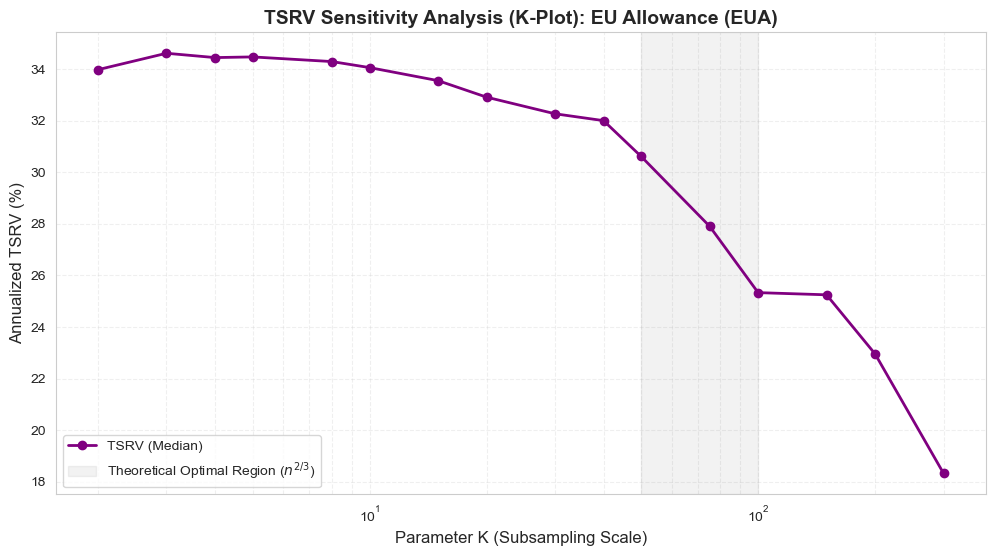

In [52]:
tsrv_data_ecf = RV.compute_tsrv_sensitivity_data(folder_ecf, "ECF", n_files=50)
RV.plot_tsrv_sensitivity(tsrv_data_ecf, "EU Allowance (EUA)")

## TSRV Calculation for every available day

## BRN

In [53]:
df_brn = RV.run_production_final(folder_brn, "BRN")
df_brn_clean = RV.keep_most_liquid_daily(df_brn)
display(df_brn_clean)

,TSRV,n_obs,K_used
Date,,,
2015-12-15,51.370989,17336,669
2015-12-16,37.273778,16695,653
2015-12-17,33.753354,14867,604
2015-12-18,46.913313,14388,591
2015-12-21,33.789078,13386,563
...,...,...,...
2021-06-01,22.259932,14749,601
2021-06-02,13.571213,11069,496
2021-06-03,20.585008,11964,523


## WBS

In [54]:
df_wti = RV.run_production_final(folder_wti, "WBS")
df_wti_clean = RV.keep_most_liquid_daily(df_wti)
display(df_wti_clean)

,TSRV,n_obs,K_used
Date,,,
2015-12-15,55.509203,2507,184
2015-12-16,42.567084,2186,168
2015-12-17,27.732652,1531,132
2015-12-18,44.327842,2107,164
2015-12-21,28.646641,1642,139
...,...,...,...
2021-06-01,22.166751,1998,158
2021-06-02,16.170732,1502,131
2021-06-03,19.007341,1742,144


## TFM

In [55]:
df_tfm = RV.run_production_final(folder_tfm, "TFM")
df_tfm_clean = RV.keep_most_liquid_daily(df_tfm)
display(df_tfm_clean)

,TSRV,n_obs,K_used
Date,,,
2015-12-23,17.830225,110,22
2016-01-06,10.598105,183,32
2016-01-07,34.120193,146,27
2016-01-08,20.389252,178,31
2016-01-11,22.746326,137,26
...,...,...,...
2022-12-13,59.183662,1765,146
2022-12-14,64.237189,2041,160
2022-12-15,39.362841,2069,162


## ECF

In [56]:
df_ecf = RV.run_production_final(folder_ecf, "ECF")
df_ecf_clean = RV.keep_most_liquid_daily(df_ecf)
display(df_ecf_clean)

,TSRV,n_obs,K_used
Date,,,
2015-12-15,22.462027,477,61
2015-12-16,17.447712,355,50
2015-12-17,16.651346,454,59
2015-12-18,19.357889,616,72
2015-12-21,15.881956,264,41
...,...,...,...
2022-12-13,31.335822,2813,199
2022-12-14,45.327402,3150,214
2022-12-15,32.678454,2424,180


## TSRV Volatility Plot + Confronto

In [57]:
# CREAZIONE DATI PULTI DEL TSRV PER PLOT
s_brn = df_brn_clean[['TSRV']].rename(columns={'TSRV': 'Brent'})
s_wti = df_wti_clean[['TSRV']].rename(columns={'TSRV': 'WTI'})
s_ttf = df_tfm_clean[['TSRV']].rename(columns={'TSRV': 'TTF_Gas'})
s_eua = df_ecf_clean[['TSRV']].rename(columns={'TSRV': 'EUA_Carbon'})
df_master = pd.concat([s_brn, s_wti, s_ttf, s_eua], axis=1)
df_master = df_master.sort_index()

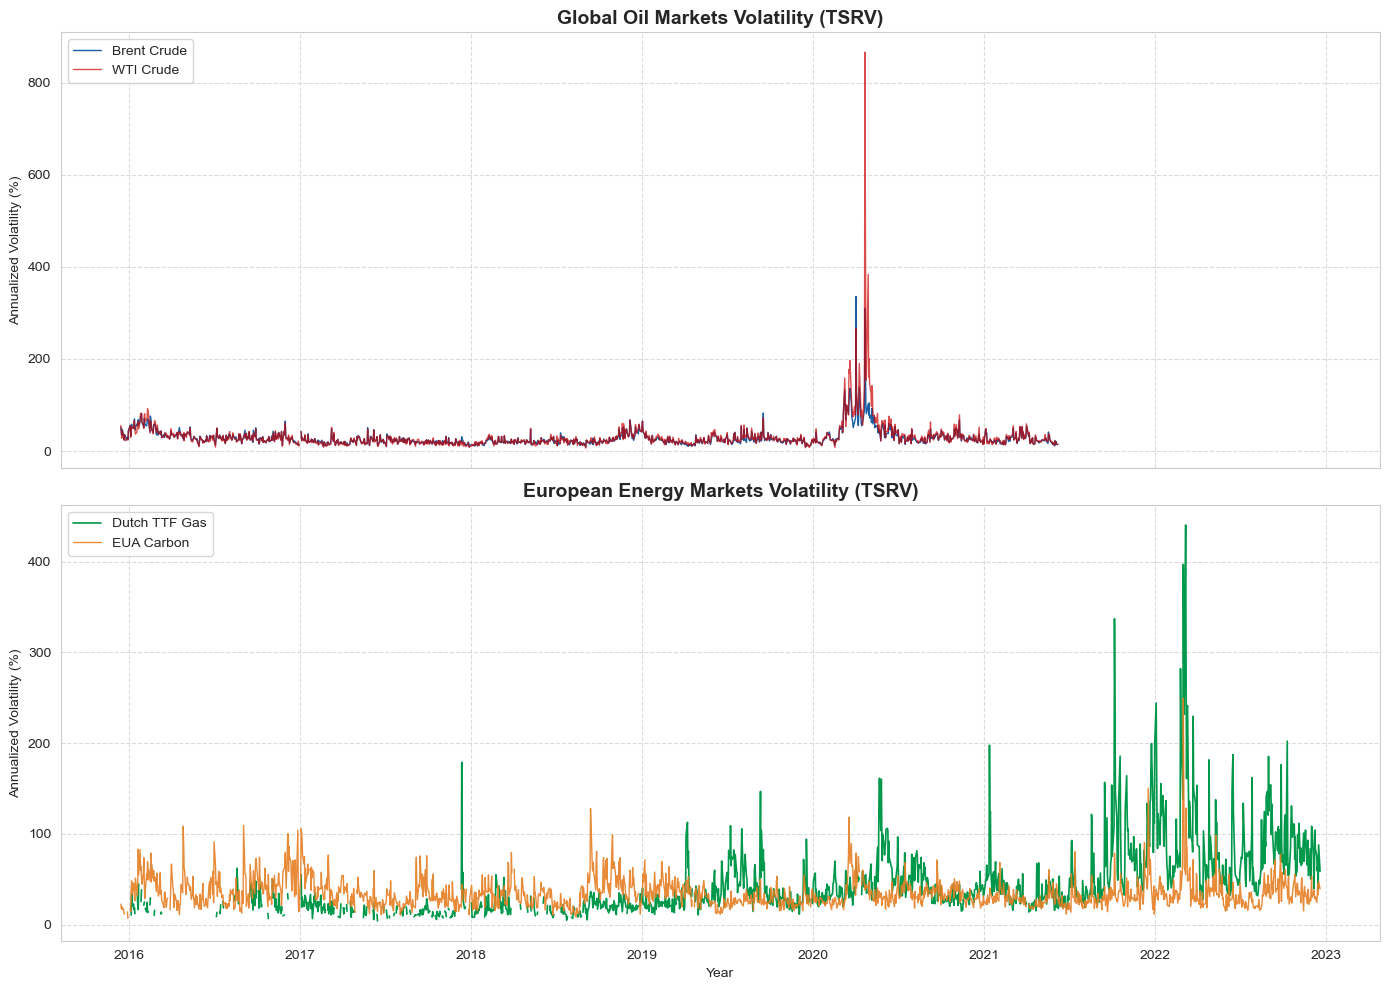

In [58]:
RV.plot_volatility_trends(df_master)

In [59]:
df_master.head(100)

,Brent,WTI,TTF_Gas,EUA_Carbon
Date,,,,
2015-12-15,51.370989,55.509203,NaN,22.462027
2015-12-16,37.273778,42.567084,NaN,17.447712
2015-12-17,33.753354,27.732652,NaN,16.651346
2015-12-18,46.913313,44.327842,NaN,19.357889
2015-12-21,33.789078,28.646641,NaN,15.881956
...,...,...,...,...
2016-04-29,37.334115,38.778082,NaN,60.030209
2016-05-02,32.954311,32.743232,NaN,33.255709
2016-05-03,36.667086,29.800764,NaN,41.630521


# LHAR - CJ

Per implementare l'equazione (4.1) del paper (il modello LHAR-CJ), dobbiamo costruire queste 4 serie storiche per ogni asset:

- $RV_t$ (Realized Volatility): Useremo però il TSRV che abbiamo già calcolato. È la misura di volatilità totale "pulita".

- $C_t$ (Continuous Volatility): Questa la stimeremo usando la Threshold Bipower Variation (TBV) sui dati a 5 minuti (per evitare il rumore microstrutturale nel calcolo dei salti).

- $J_t$ (Jump Component): Sarà la differenza: $J_t = \max(0, RV_t - C_t)$, ma solo se il test statistico Z supera la soglia critica (99.9%).
    
- $r_t^-$ (Leverage Effect): I rendimenti negativi giornalieri. Il paper dimostra che i crolli passati predicono la volatilità futura meglio dei rialzi.

### Threshold Bipower Variation (TBPV)
$$
\text{TBPV}_t = \frac{\pi}{2} \frac{M}{M-2} \sum_{j=0}^{M-2} |\Delta_{t,j} X| \cdot |\Delta_{t,j+1} X| \times I_{\{|\Delta_{t,j} X|^2 \leq \vartheta_{j-1}\}} I_{\{|\Delta_{t,j+1} X|^2 \leq \vartheta_j\}}
$$

Qui definiamo il threshold recuperato dai paper precedenti di Corsi & Renò:
$$\vartheta_t = c_{\vartheta} \cdot \sqrt{\hat{V}_t}$$
Dove:

- $\hat{V}_t$ è una stima della varianza locale (deviazione standard al quadrato).

- $c_{\vartheta}$ è la costante che cerchi (il 3).

Nel paper del 2010, gli autori conducono simulazioni Monte Carlo approfondite e dimostrano che:Un valore di $c_{\vartheta} = 3$ offre il miglior compromesso tra il rimuovere troppi dati (se la soglia è bassa) e non identificare i salti (se la soglia è alta).A volte usano anche 4 o 5 per test di robustezza, ma 3 è lo standard di settore.

### Cleaning Data

In [60]:
folder_brn = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/BRN"
folder_wti = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/WBS"
folder_tfm = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/TFM"
folder_ecf = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/ECF"

df_final_brn = V_F_S.process_asset_folder(folder_brn, "BRN")
df_final_wbs = V_F_S.process_asset_folder(folder_wti, "WBS")
df_final_tfm = V_F_S.process_asset_folder(folder_tfm, "TFM")
df_final_ecf = V_F_S.process_asset_folder(folder_ecf, "ECF")

### Diagnostica per WTI per incongruenza del livello dei prezzi e salti enormi improvvisi

In [61]:
def diagnose_wti_unified_and_sorted(folder_path):
    print(f"--- DIAGNOSTICA GLOBALE WTI (UNIFIED) ---")
    print("1. Caricamento di tutti i file in memoria (solo Prezzo e Data)...")
    
    all_files = sorted([f for f in os.listdir(folder_path) if f.startswith('WBS') and f.endswith('.csv')])
    list_of_dfs = []
    
    for filename in all_files:
        file_path = os.path.join(folder_path, filename)
        try:
            # Leggiamo solo le prime due colonne per risparmiare memoria
            # Assumiamo che le colonne siano 'Price ($)' e 'Datetime' o simili
            # Usiamo usecols se sapessimo i nomi precisi, ma per sicurezza leggiamo e filtriamo
            df_temp = pd.read_csv(file_path)
            
            # Normalizzazione Nomi Colonne
            if 'Price ($)' in df_temp.columns:
                df_temp = df_temp[['Price ($)', 'Datetime']].rename(columns={'Price ($)': 'Price', 'Datetime': 'Date'})
            elif 'Close' in df_temp.columns:
                 # Cerca la colonna data
                date_col = 'Date' if 'Date' in df_temp.columns else df_temp.columns[0]
                df_temp = df_temp[['Close', date_col]].rename(columns={'Close': 'Price', date_col: 'Date'})
            else:
                # Fallback sulle posizioni: colonna 0 = Prezzo, colonna 1 = Data (o viceversa, controlla i tuoi csv)
                # Di solito nei tuoi file la colonna 0 è il Prezzo
                df_temp = df_temp.iloc[:, [0, 1]]
                df_temp.columns = ['Price', 'Date']
            
            list_of_dfs.append(df_temp)
            
        except Exception as e:
            print(f"Errore caricamento {filename}: {e}")

    if not list_of_dfs:
        print("Nessun file trovato.")
        return

    print(f"2. Unione di {len(list_of_dfs)} file in un unico DataFrame...")
    df_full = pd.concat(list_of_dfs, ignore_index=True)
    
    print("3. Ordinamento temporale (questo potrebbe richiedere qualche secondo)...")
    df_full['Date'] = pd.to_datetime(df_full['Date'], format='mixed', utc=True)
    df_full.sort_values('Date', inplace=True)
    
    print(f"Dataset Unico creato: {len(df_full)} tick totali.")
    
    # --- CONTROLLI ---
    prices = df_full['Price'].values
    
    # A. Prezzi Negativi/Zero (Impossibili per Log-Model)
    neg_zeros = prices[prices <= 0.01]
    num_neg = len(neg_zeros)
    
    print("\n--- RISULTATI ANALISI GLOBALE ---")
    if num_neg > 0:
        print(f"[CRITICO] Trovati {num_neg} tick con Prezzo <= 0.01")
        print(f"Esempio valori: {neg_zeros[:5]}")
        print("Questi DEVONO essere rimossi per far girare il modello HAR.")
    else:
        print("[OK] Nessun prezzo negativo o zero trovato.")

    # B. Flash Crash (Salti > 15% tra un tick e l'altro nel flusso ordinato)
    print("Analisi salti anomali (>15%)...")
    
    # Filtriamo i prezzi validi per il calcolo %
    valid_prices = prices[prices > 0.01]
    
    if len(valid_prices) > 1:
        # Calcolo variazione % tick-by-tick
        pct_changes = np.abs(np.diff(valid_prices) / valid_prices[:-1])
        num_crashes = np.sum(pct_changes > 0.15)
        
        if num_crashes > 0:
            print(f"[ALLARME] Trovati {num_crashes} 'Flash Crash' (Salti > 15% in un tick)")
            print("Poiché i dati sono ORA ordinati perfettamente, questi sono errori del data-feed.")
        else:
            print("[OK] Nessun salto anomalo trovato dopo l'ordinamento!")
            print("Conclusione: I 'crash' precedenti erano dovuti solo al disordine dei file.")
            
    print("="*40)

# ESEGUI
path_wti = "/Users/viscontitommi/Desktop/S.P./Data/Raw_Data/WBS" # Controlla che il path sia giusto
diagnose_wti_unified_and_sorted(path_wti)

--- DIAGNOSTICA GLOBALE WTI (UNIFIED) ---
1. Caricamento di tutti i file in memoria (solo Prezzo e Data)...
2. Unione di 86 file in un unico DataFrame...
3. Ordinamento temporale (questo potrebbe richiedere qualche secondo)...
Dataset Unico creato: 8281214 tick totali.

--- RISULTATI ANALISI GLOBALE ---
[CRITICO] Trovati 97 tick con Prezzo <= 0.01
Esempio valori: [ 0.01  0.01 -0.02 -0.08 -0.08]
Questi DEVONO essere rimossi per far girare il modello HAR.
Analisi salti anomali (>15%)...
[ALLARME] Trovati 71389 'Flash Crash' (Salti > 15% in un tick)
Poiché i dati sono ORA ordinati perfettamente, questi sono errori del data-feed.


In [62]:
df_daily_brn = V_F_S.calculate_jump_math_daily(df_final_brn)
df_daily_wbs = V_F_S.calculate_jump_math_daily(df_final_wbs)
df_daily_tfm = V_F_S.calculate_jump_math_daily(df_final_tfm)
df_daily_ecf = V_F_S.calculate_jump_math_daily(df_final_ecf)

### HAR Variables Calculation

In [63]:
df_lhar_brn = lhar_cj.calculate_har_variables(df_daily_brn)
df_lhar_wbs = lhar_cj.calculate_har_variables(df_daily_wbs)
df_lhar_tfm = lhar_cj.calculate_har_variables(df_daily_tfm)
df_lhar_ecf = lhar_cj.calculate_har_variables(df_daily_ecf)

# LHAR-CJ Model Results (OLS Regression)

## BRN

In [64]:
lhar_cj_brn = lhar_cj.run_lhar_cj_model(df_lhar_brn, h=1)
print(lhar_cj_brn.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     180.5
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          1.12e-225
Time:                        00:04:56   Log-Likelihood:                -1294.9
No. Observations:                1385   AIC:                             2610.
Df Residuals:                    1375   BIC:                             2662.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.0810      0.103    -29.997   

## WBS

In [65]:
lhar_cj_wbs = lhar_cj.run_lhar_cj_model(df_lhar_wbs, h=1)
print(lhar_cj_wbs.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     89.02
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          2.34e-130
Time:                        00:04:56   Log-Likelihood:                -1896.7
No. Observations:                1380   AIC:                             3813.
Df Residuals:                    1370   BIC:                             3866.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -4.3898      0.158    -27.711   

## TFM

In [66]:
lhar_cj_tfm = lhar_cj.run_lhar_cj_model(df_lhar_tfm, h=1)
print(lhar_cj_tfm.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.341
Method:                 Least Squares   F-statistic:                     56.13
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           5.61e-90
Time:                        00:04:56   Log-Likelihood:                -3522.3
No. Observations:                1735   AIC:                             7065.
Df Residuals:                    1725   BIC:                             7119.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.7237      0.195    -19.143   

## ECF

In [67]:
lhar_cj_ecf = lhar_cj.run_lhar_cj_model(df_lhar_ecf, h=1)
print(lhar_cj_ecf.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     39.03
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           9.50e-64
Time:                        00:04:56   Log-Likelihood:                -2673.0
No. Observations:                1771   AIC:                             5366.
Df Residuals:                    1761   BIC:                             5421.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -4.1013      0.492     -8.343   

L'errore "Condition number is large" indica Multicollinearità. In parole semplici: le variabili "day", "week" e "mon" dicono quasi la stessa cosa, quindi il modello va in confusione (ecco perché vediamo segni strani come lev_mon positivo). 

Questo succede poichè nella definizione standard (HAR):

- La media Settimanale (5 giorni) contiene al suo interno il dato daily.

- La media Mensile (22 giorni) contiene al suo interno la media weekly. Sono come matrioske: una dentro l'altra. 

Questo crea una correlazione altissima (quasi 100%) tra le variabili.

La Soluzione: 

"Ortogonalizzazione" (Non-Overlapping) dove cerchiamo di separare le "matrioske". Invece di usare le medie sovrapposte, usiamo finestre temporali distinte:

- Daily: Solo ieri ($t-1$).

- Weekly: La media dal giorno $t-2$ al $t-5$ (escludendo ieri).

- Monthly: La media dal giorno $t-6$ al $t-22$ (escludendo l'ultima settimana).

# LHAR-C-CJ Model

## BRN

In [68]:
lhar_c_cj_brn = lhar_cj.run_lhar_c_cj_model(df_lhar_brn, h=1)
print(lhar_c_cj_brn.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.703
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     345.2
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:04:56   Log-Likelihood:                -1910.0
No. Observations:                1385   AIC:                             3840.
Df Residuals:                    1375   BIC:                             3892.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.4947      0.100     -4.968   

## WBS

In [69]:
lhar_c_cj_wbs = lhar_cj.run_lhar_c_cj_model(df_lhar_wbs, h=1)
print(lhar_c_cj_wbs.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     207.6
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          8.42e-249
Time:                        00:04:56   Log-Likelihood:                -2103.5
No. Observations:                1383   AIC:                             4227.
Df Residuals:                    1373   BIC:                             4279.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.7701      0.146     -5.264   

## TFM

In [70]:
lhar_c_cj_tfm = lhar_cj.run_lhar_c_cj_model(df_lhar_tfm, h=1)
print(lhar_c_cj_tfm.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     221.0
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          7.25e-281
Time:                        00:04:56   Log-Likelihood:                -3434.0
No. Observations:                1759   AIC:                             6888.
Df Residuals:                    1749   BIC:                             6943.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.6125      0.165     -3.716   

## ECF

In [71]:
lhar_c_cj_ecf = lhar_cj.run_lhar_c_cj_model(df_lhar_ecf, h=1)
print(lhar_c_cj_ecf.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     53.14
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.03e-85
Time:                        00:04:56   Log-Likelihood:                -2286.9
No. Observations:                1773   AIC:                             4594.
Df Residuals:                    1763   BIC:                             4649.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -2.0169      0.408     -4.942   

# LHAR-J-CJ Model

## BRN

In [72]:
lhar_j_cj_brn = lhar_cj.run_lhar_j_cj_model(df_lhar_brn, h=1)
print(lhar_j_cj_brn.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     2.255
Date:                Mon, 13 Apr 2026   Prob (F-statistic):             0.0167
Time:                        00:04:56   Log-Likelihood:                 9656.1
No. Observations:                1385   AIC:                        -1.929e+04
Df Residuals:                    1375   BIC:                        -1.924e+04
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     7.187e-06   1.82e-05      0.395   

## WBS

In [73]:
lhar_j_cj_wbs = lhar_cj.run_lhar_j_cj_model(df_lhar_wbs, h=1)
print(lhar_j_cj_wbs.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     4.947
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.45e-06
Time:                        00:04:56   Log-Likelihood:                 9011.8
No. Observations:                1385   AIC:                        -1.800e+04
Df Residuals:                    1375   BIC:                        -1.795e+04
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -2.899e-05    3.2e-05     -0.905   

## TFM

In [74]:
lhar_j_cj_tfm = lhar_cj.run_lhar_j_cj_model(df_lhar_tfm, h=1)
print(lhar_j_cj_tfm.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     4.261
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.74e-05
Time:                        00:04:56   Log-Likelihood:                 3508.8
No. Observations:                1766   AIC:                            -6998.
Df Residuals:                    1756   BIC:                            -6943.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0042      0.004      1.041   

## ECF

In [75]:
lhar_j_cj_ecf = lhar_cj.run_lhar_j_cj_model(df_lhar_ecf, h=1)
print(lhar_j_cj_ecf.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     4.501
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           7.20e-06
Time:                        00:04:56   Log-Likelihood:                 11546.
No. Observations:                1774   AIC:                        -2.307e+04
Df Residuals:                    1764   BIC:                        -2.302e+04
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -4.806e-05      0.000     -0.370   

# Risk-Return Trade-Off

## BRN

In [76]:
df_final_brn_ret = df_final_brn['Price ($)'].resample('D').last().dropna()
daily_returns_brn = np.log(df_final_brn_ret).diff().dropna()
lhar_cj_pred_brn = lhar_cj_brn.fittedvalues
risk_ret_brn = lhar_cj.analyze_risk_return_tradeoff(daily_returns_brn, lhar_cj_pred_brn)
print(risk_ret_brn.summary())

                            OLS Regression Results                            
Dep. Variable:                    r_t   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5334
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.465
Time:                        00:04:57   Log-Likelihood:                 2952.0
No. Observations:                1385   AIC:                            -5900.
Df Residuals:                    1383   BIC:                            -5890.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.634      0.5

Nel mercato del petrolio, la volatilità esplode tipicamente durante gli shock di offerta o le crisi geopolitiche. 

### L'interpretazione "Bearish" della Volatilità nel Brent

Nel tuo dataset, il modello sta catturando questo fenomeno:

Quando il modello prevede un aumento della volatilità, sta in realtà prevedendo una fase di stress o di crollo dei prezzi.
    
Pensa ai grandi movimenti del petrolio (es. crisi 2008, crollo COVID 2020):

- Il prezzo crolla verticalmente (rendimenti fortemente negativi).

- La volatilità schizza alle stelle.

Quindi, statisticamente, Alta Volatilità prevista $\rightarrow$ Rendimenti Negativi. Ecco perché il tuo coefficiente $\beta$ è negativo.

## WBS

In [77]:
df_final_wbs_ret = df_final_wbs['Price ($)'].resample('D').last().dropna()
daily_returns_wbs = np.log(df_final_wbs_ret).diff().dropna()
lhar_cj_pred_wbs = lhar_cj_wbs.fittedvalues
risk_ret_wbs = lhar_cj.analyze_risk_return_tradeoff(daily_returns_wbs, lhar_cj_pred_wbs)
print(risk_ret_wbs.summary())

                            OLS Regression Results                            
Dep. Variable:                    r_t   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     191.2
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           8.07e-41
Time:                        00:04:57   Log-Likelihood:                 2649.5
No. Observations:                1380   AIC:                            -5295.
Df Residuals:                    1378   BIC:                            -5285.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.001      1.802      0.0

## TFM

In [78]:
df_final_tfm_ret = df_final_tfm['Price (€)'].resample('D').last().dropna()
daily_returns_tfm = np.log(df_final_tfm_ret).diff().dropna()
lhar_cj_pred_tfm = lhar_cj_tfm.fittedvalues
risk_ret_tfm = lhar_cj.analyze_risk_return_tradeoff(daily_returns_tfm, lhar_cj_pred_tfm)
print(risk_ret_tfm.summary())

                            OLS Regression Results                            
Dep. Variable:                    r_t   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7803
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.377
Time:                        00:04:57   Log-Likelihood:                 1823.4
No. Observations:                1735   AIC:                            -3643.
Df Residuals:                    1733   BIC:                            -3632.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0018      0.002      0.871      0.3

## ECF

In [79]:
df_final_ecf_ret = df_final_ecf['Price (€)'].resample('D').last().dropna()
daily_returns_ecf = np.log(df_final_ecf_ret).diff().dropna()
lhar_cj_pred_ecf = lhar_cj_ecf.fittedvalues
risk_ret_ecf = lhar_cj.analyze_risk_return_tradeoff(daily_returns_ecf, lhar_cj_pred_ecf)
print(risk_ret_ecf.summary())

                            OLS Regression Results                            
Dep. Variable:                    r_t   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     60.32
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.36e-14
Time:                        00:04:57   Log-Likelihood:                 3683.0
No. Observations:                1771   AIC:                            -7362.
Df Residuals:                    1769   BIC:                            -7351.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0057      0.001      6.289      0.0

# Is Leverage Effect Induced by Jumps?

## BRN

In [80]:
lhar_cj_plus_brn = lhar_cj.run_lhar_cj_plus_model(df_lhar_brn, h=1)
print(lhar_cj_plus_brn.summary())

                            OLS Regression Results                            
Dep. Variable:               target_h   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     165.4
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          1.57e-227
Time:                        00:04:57   Log-Likelihood:                -1294.2
No. Observations:                1385   AIC:                             2610.
Df Residuals:                    1374   BIC:                             2668.
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -3.0835      0.103    -30.005

## WBS

In [81]:
lhar_cj_plus_wbs = lhar_cj.run_lhar_cj_plus_model(df_lhar_wbs, h=1)
print(lhar_cj_plus_wbs.summary())

                            OLS Regression Results                            
Dep. Variable:               target_h   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     80.68
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          3.32e-130
Time:                        00:04:57   Log-Likelihood:                -1896.5
No. Observations:                1380   AIC:                             3815.
Df Residuals:                    1369   BIC:                             3873.
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -4.3892      0.158    -27.730

## TFM

In [82]:
lhar_cj_plus_tfm = lhar_cj.run_lhar_cj_plus_model(df_lhar_tfm, h=1)
print(lhar_cj_plus_tfm.summary())

                            OLS Regression Results                            
Dep. Variable:               target_h   R-squared:                       0.345
Model:                            OLS   Adj. R-squared:                  0.341
Method:                 Least Squares   F-statistic:                     52.08
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.05e-91
Time:                        00:04:57   Log-Likelihood:                -3521.6
No. Observations:                1735   AIC:                             7065.
Df Residuals:                    1724   BIC:                             7125.
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -3.7307      0.194    -19.218

## ECF

In [83]:
lhar_cj_plus_ecf = lhar_cj.run_lhar_cj_plus_model(df_lhar_ecf, h=1)
print(lhar_cj_plus_ecf.summary())

                            OLS Regression Results                            
Dep. Variable:               target_h   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     41.13
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.78e-73
Time:                        00:04:57   Log-Likelihood:                -2672.5
No. Observations:                1771   AIC:                             5367.
Df Residuals:                    1760   BIC:                             5427.
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -4.1198      0.493     -8.360

# Out-of-Sample Analysis

## BRN

In [84]:
oos_res_brn, mz_res_brn = lhar_cj.run_oos_lhar_cj_expanding(df_lhar_brn, start_fraction=0.75)
print(mz_res_brn.summary())

RMSE: 0.7620
                            OLS Regression Results                            
Dep. Variable:               Realized   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     1296.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          7.15e-119
Time:                        00:04:59   Log-Likelihood:                -397.71
No. Observations:                 347   AIC:                             799.4
Df Residuals:                     345   BIC:                             807.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0992      0.157      0

### Out-of-Sample Mincer-Zarnowitz R<sup>2</sup>

Mincer-Zarnovitz R²=0.7231 | RMSE=0.8813
Mincer-Zarnovitz R²=0.6298 | RMSE=0.9946
Mincer-Zarnovitz R²=0.5179 | RMSE=1.1321
Mincer-Zarnovitz R²=0.2286 | RMSE=1.4391
Mincer-Zarnovitz R²=0.7277 | RMSE=0.8749
Mincer-Zarnovitz R²=0.6316 | RMSE=0.9939
Mincer-Zarnovitz R²=0.5179 | RMSE=1.1351
Mincer-Zarnovitz R²=0.2272 | RMSE=1.4466
Mincer-Zarnovitz R²=0.7898 | RMSE=0.7620
Mincer-Zarnovitz R²=0.7008 | RMSE=0.8952
Mincer-Zarnovitz R²=0.5864 | RMSE=1.0557
Mincer-Zarnovitz R²=0.2858 | RMSE=1.4030


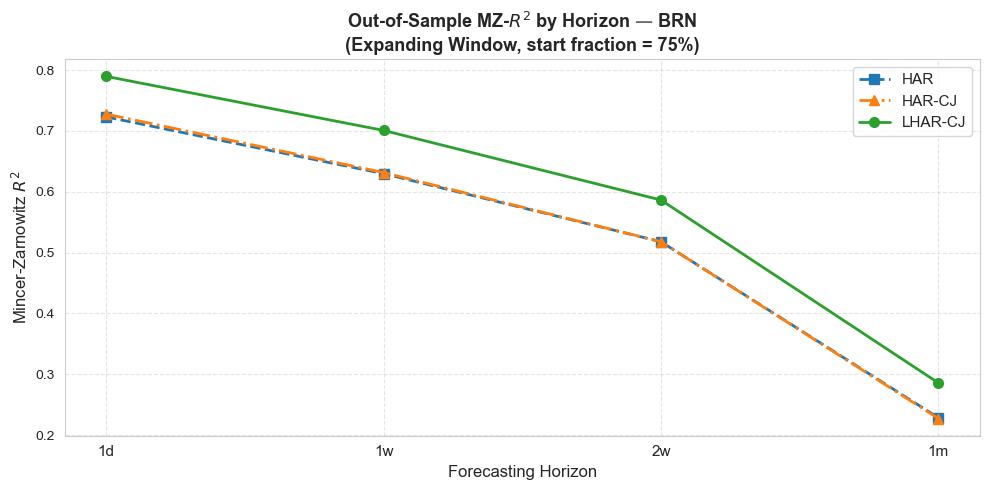

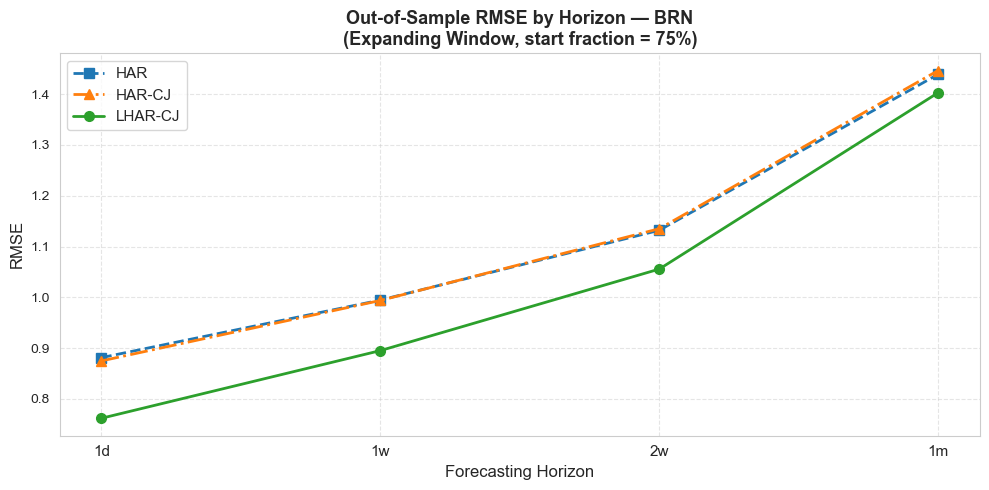

In [85]:
oos_multi_brn = lhar_cj.run_oos_multihorizon(df_lhar_brn, horizons=[1, 5, 10, 22], start_fraction=0.75)
lhar_cj.plot_mz_r2_figure4(oos_multi_brn, asset_name='BRN')
lhar_cj.plot_rmse_figure4(oos_multi_brn,  asset_name='BRN')

## WBS

In [86]:
oos_res_wbs, mz_res_wbs = lhar_cj.run_oos_lhar_cj_expanding(df_lhar_wbs, start_fraction=0.75)
print(mz_res_wbs.summary())

RMSE: 1.0555
                            OLS Regression Results                            
Dep. Variable:               Realized   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     642.2
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.37e-80
Time:                        00:05:17   Log-Likelihood:                -507.72
No. Observations:                 345   AIC:                             1019.
Df Residuals:                     343   BIC:                             1027.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1096      0.289      0

### Out-of-Sample Mincer-Zarnowitz R<sup>2</sup>

Mincer-Zarnovitz R²=0.6039 | RMSE=1.1640
Mincer-Zarnovitz R²=0.6319 | RMSE=1.0399
Mincer-Zarnovitz R²=0.5753 | RMSE=1.0989
Mincer-Zarnovitz R²=0.3958 | RMSE=1.3304
Mincer-Zarnovitz R²=0.6118 | RMSE=1.1572
Mincer-Zarnovitz R²=0.6299 | RMSE=1.0453
Mincer-Zarnovitz R²=0.5661 | RMSE=1.1127
Mincer-Zarnovitz R²=0.3815 | RMSE=1.3487
Mincer-Zarnovitz R²=0.6519 | RMSE=1.0555
Mincer-Zarnovitz R²=0.6764 | RMSE=0.9425
Mincer-Zarnovitz R²=0.6081 | RMSE=1.0284
Mincer-Zarnovitz R²=0.4287 | RMSE=1.2831


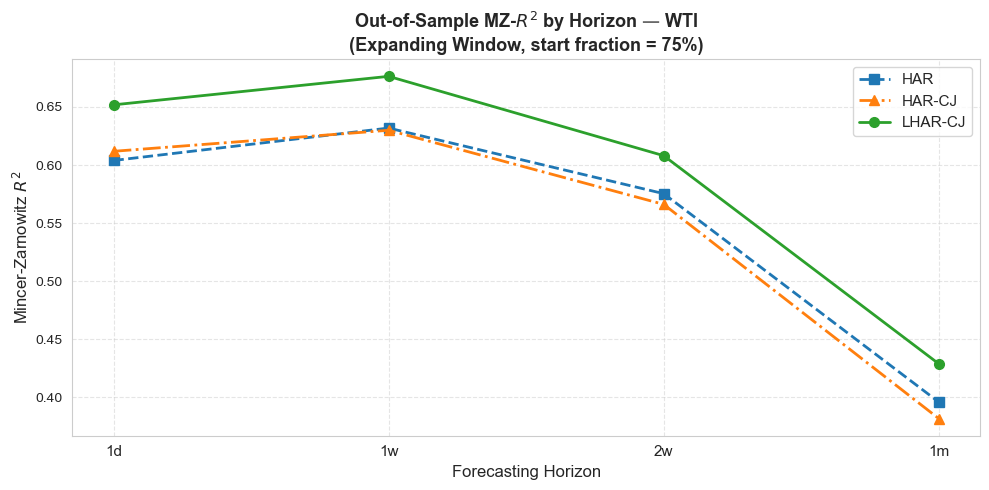

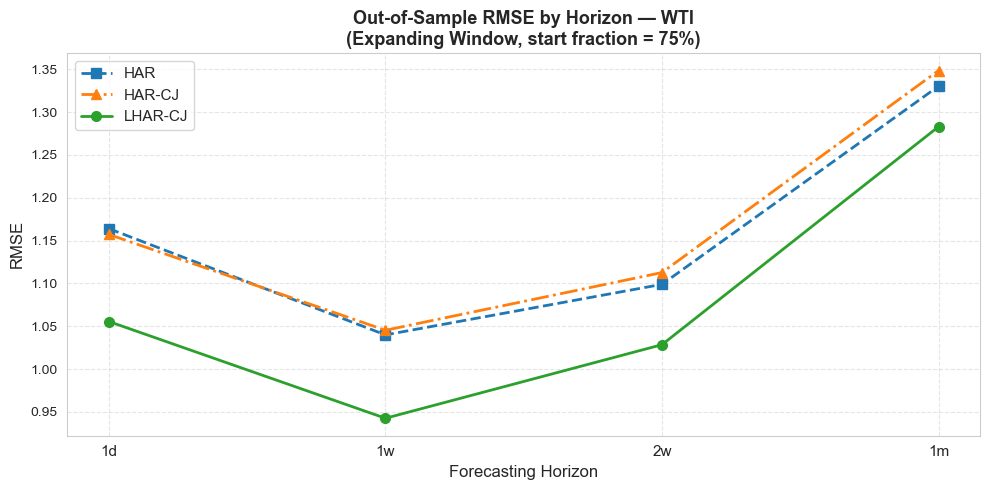

In [87]:
oos_multi_wbs = lhar_cj.run_oos_multihorizon(df_lhar_wbs, horizons=[1, 5, 10, 22], start_fraction=0.75)
lhar_cj.plot_mz_r2_figure4(oos_multi_wbs, asset_name='WTI')
lhar_cj.plot_rmse_figure4(oos_multi_wbs,  asset_name='WTI')

## TFM

In [88]:
oos_res_tfm, mz_res_tfm = lhar_cj.run_oos_lhar_cj_expanding(df_lhar_tfm, start_fraction=0.75)
print(mz_res_tfm.summary())

RMSE: 1.1687
                            OLS Regression Results                            
Dep. Variable:               Realized   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     282.6
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           3.71e-49
Time:                        00:05:34   Log-Likelihood:                -669.30
No. Observations:                 434   AIC:                             1343.
Df Residuals:                     432   BIC:                             1351.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5841      0.513      5

### Out-of-Sample Mincer-Zarnowitz R<sup>2</sup>

Mincer-Zarnovitz R²=0.3726 | RMSE=1.1762
Mincer-Zarnovitz R²=0.3976 | RMSE=1.0308
Mincer-Zarnovitz R²=0.4190 | RMSE=1.0170
Mincer-Zarnovitz R²=0.3736 | RMSE=1.0505
Mincer-Zarnovitz R²=0.4086 | RMSE=1.1718
Mincer-Zarnovitz R²=0.4459 | RMSE=0.9393
Mincer-Zarnovitz R²=0.4582 | RMSE=0.9059
Mincer-Zarnovitz R²=0.4009 | RMSE=0.9418
Mincer-Zarnovitz R²=0.3955 | RMSE=1.1687
Mincer-Zarnovitz R²=0.4184 | RMSE=0.9462
Mincer-Zarnovitz R²=0.4092 | RMSE=0.9226
Mincer-Zarnovitz R²=0.3190 | RMSE=0.9765


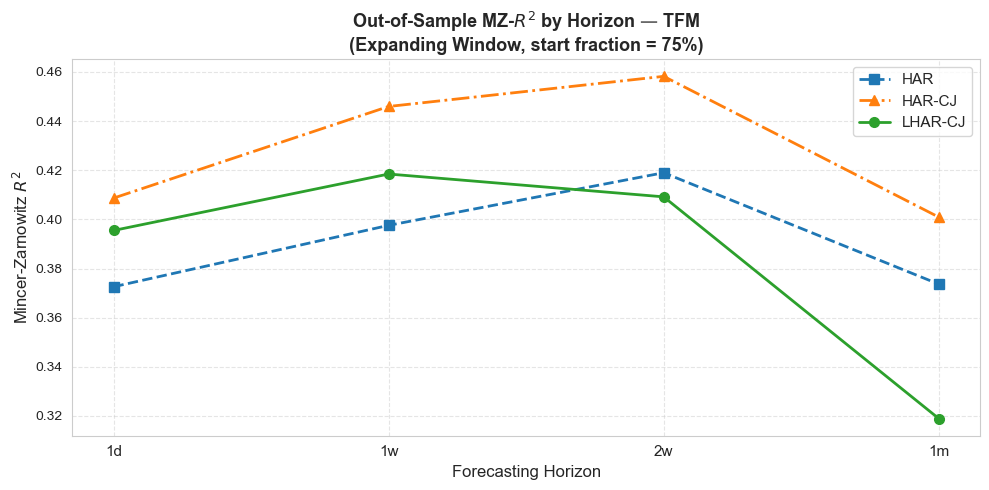

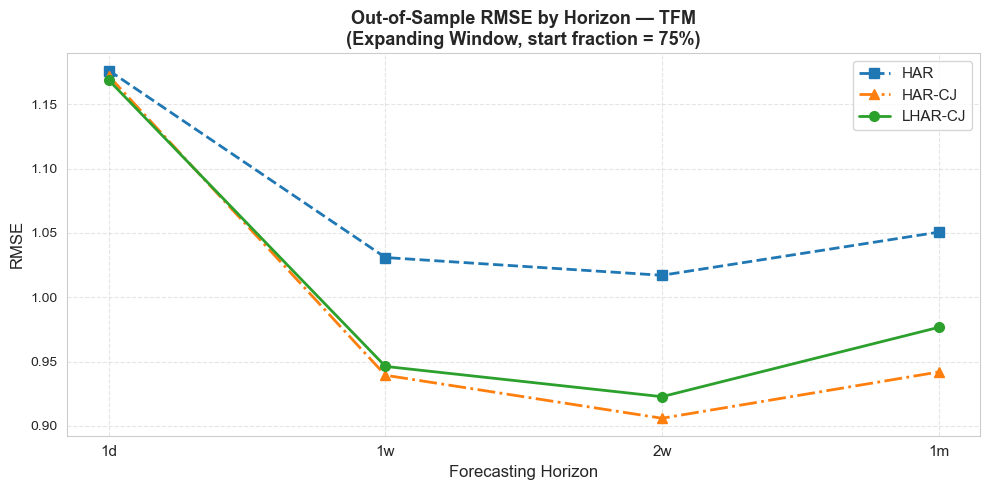

In [89]:
oos_multi_tfm = lhar_cj.run_oos_multihorizon(df_lhar_tfm, horizons=[1, 5, 10, 22], start_fraction=0.75)
lhar_cj.plot_mz_r2_figure4(oos_multi_tfm, asset_name='TFM')
lhar_cj.plot_rmse_figure4(oos_multi_tfm,  asset_name='TFM')

## ECF

In [90]:
oos_res_ecf, mz_res_ecf = lhar_cj.run_oos_lhar_cj_expanding(df_lhar_ecf, start_fraction=0.75)
print(mz_res_ecf.summary())

RMSE: 0.8668
                            OLS Regression Results                            
Dep. Variable:               Realized   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     149.8
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           7.40e-30
Time:                        00:05:55   Log-Likelihood:                -506.41
No. Observations:                 443   AIC:                             1017.
Df Residuals:                     441   BIC:                             1025.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7028      0.418     -6

### Out-of-Sample Mincer-Zarnowitz R<sup>2</sup>

Mincer-Zarnovitz R²=0.2986 | RMSE=0.8476
Mincer-Zarnovitz R²=0.3529 | RMSE=0.6252
Mincer-Zarnovitz R²=0.2641 | RMSE=0.6127
Mincer-Zarnovitz R²=0.1705 | RMSE=0.5923
Mincer-Zarnovitz R²=0.2274 | RMSE=0.8939
Mincer-Zarnovitz R²=0.2521 | RMSE=0.6597
Mincer-Zarnovitz R²=0.1714 | RMSE=0.6449
Mincer-Zarnovitz R²=0.0852 | RMSE=0.6185
Mincer-Zarnovitz R²=0.2536 | RMSE=0.8668
Mincer-Zarnovitz R²=0.2608 | RMSE=0.6506
Mincer-Zarnovitz R²=0.1713 | RMSE=0.6412
Mincer-Zarnovitz R²=0.0828 | RMSE=0.6178


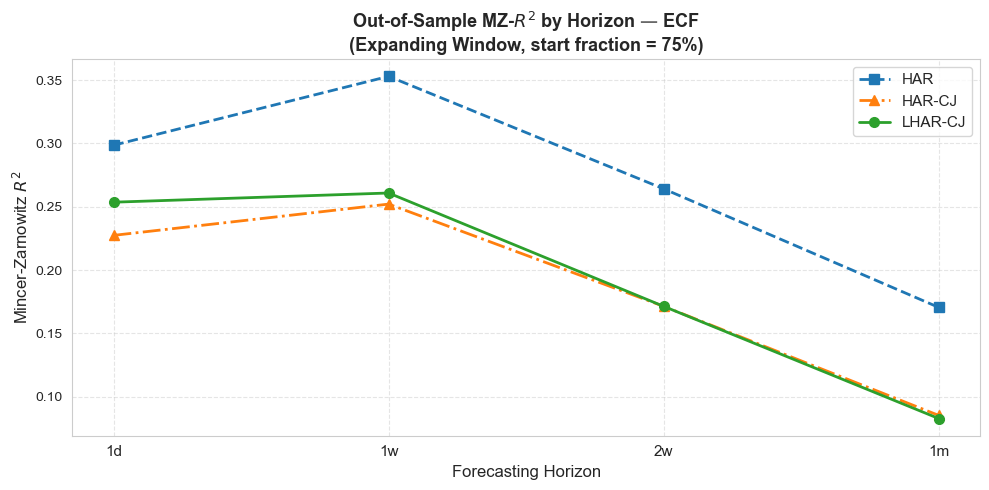

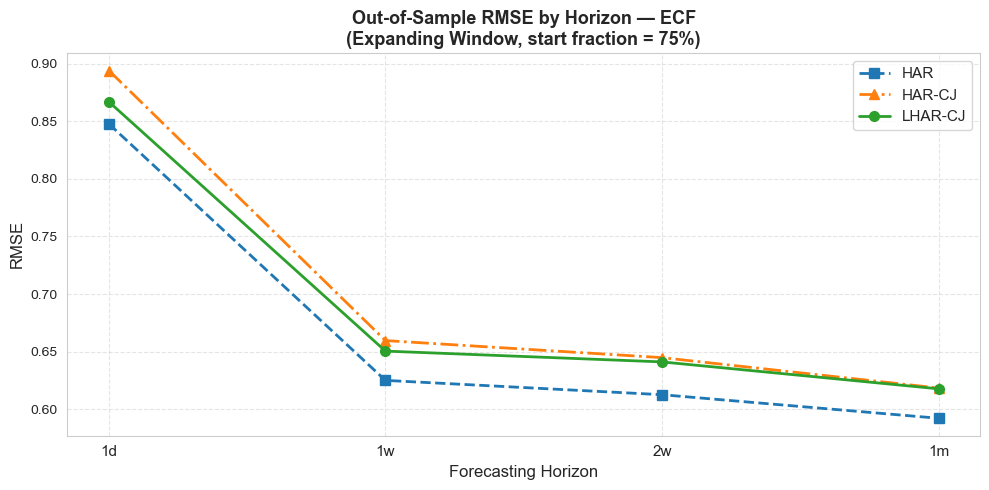

In [91]:
oos_multi_ecf = lhar_cj.run_oos_multihorizon(df_lhar_ecf, horizons=[1, 5, 10, 22], start_fraction=0.75)
lhar_cj.plot_mz_r2_figure4(oos_multi_ecf, asset_name='ECF')
lhar_cj.plot_rmse_figure4(oos_multi_ecf,  asset_name='ECF')

# Continous Time Models